In [1]:
!nvidia-smi

Thu Aug  6 12:47:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             28W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf

# ----------------- Kaggle GPU Setup & Verification -----------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable dynamic memory allocation on Kaggle P100 GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"🚀 Kaggle GPU detected and initialized: {tf.test.gpu_device_name()}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected! Make sure GPU accelerator (P100) is turned ON in Kaggle Notebook Settings.")

🚀 Kaggle GPU detected and initialized: /device:GPU:0


I0000 00:00:1786020481.125305      58 gpu_device.cc:2020] Created device /device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Loading of Dataset

In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/danishjmeo/281k-patient-dataset-for-multi-disease-prediction/Data Warehouse Multiclass.csv")
df.head()

,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


In [4]:
df.shape

(280985, 39)

## Dropping Irrelevant Features

In [5]:
df.drop(columns=['label', 'disease_flags', 'diabetes', 'hypertension', 'heart_disease', 'source_dataset', 'age_level', 'age_normalized', 'bmi_level', 'high_blood_pressure', 'blood_pressure', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'composite_key'], inplace=True)

In [6]:
df.shape

(280985, 25)

## Dropping Duplicate Rows

In [7]:
df.duplicated().sum()

np.int64(2284)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(278701, 25)

## Checking Null Values

In [10]:
df.isnull().sum()

gender                0
smoking               0
age                   0
bmi                   0
HbA1c_level           0
glucose               0
cholesterol           0
sleep_hours           0
triglycerides         0
physical_activity     0
family_history        0
stress_level          0
sugar_consumption     0
crp_level             0
homocysteine_level    0
systolic_bp           0
diastolic_bp          0
alcohol_intake        0
salt_intake           0
heart_rate            0
hdl                   0
ldl                   0
education_level       0
employment_status     0
sublabel              0
dtype: int64

In [11]:
numerical_features = df.select_dtypes(include='number').columns
numerical_features

Index(['age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours',
       'triglycerides', 'crp_level', 'homocysteine_level', 'systolic_bp',
       'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl',
       'ldl'],
      dtype='object')

In [12]:
len(numerical_features)

16

## Outlier Analysis

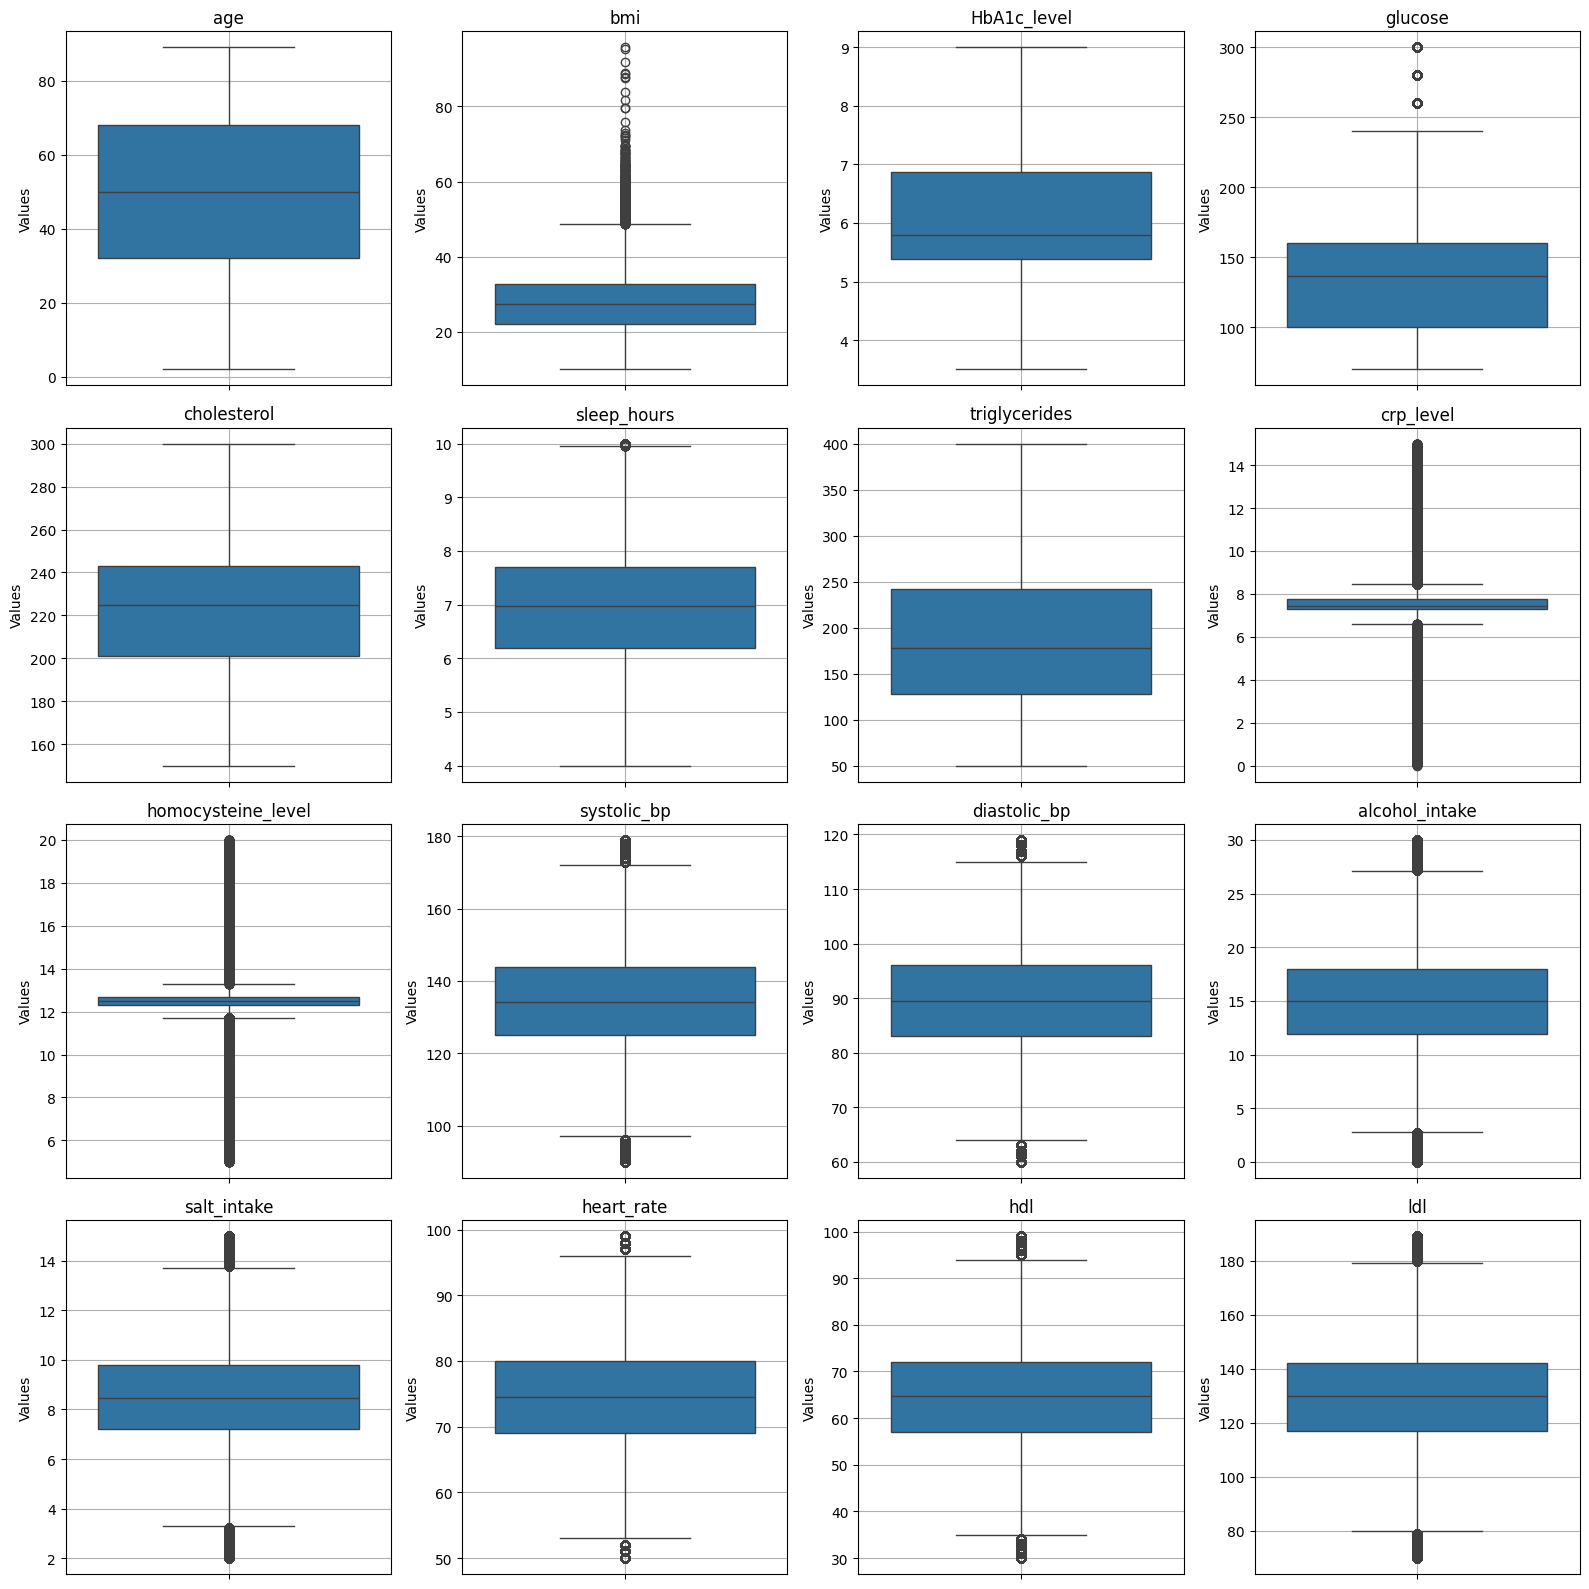

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

n_rows = 4
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for index, column in enumerate(numerical_features):
    sns.boxplot(data=df[column], ax=axes[index])
    axes[index].set_title(column)
    axes[index].set_ylabel('Values')
    axes[index].grid(True)
    
for i in range(len(numerical_features), len(axes)):
    plt.delaxes(axes[i])
    
plt.tight_layout()
plt.show()

In [14]:
categorical_features = df.select_dtypes(include='object').columns
categorical_features

Index(['gender', 'smoking', 'physical_activity', 'family_history',
       'stress_level', 'sugar_consumption', 'education_level',
       'employment_status', 'sublabel'],
      dtype='object')

In [15]:
len(categorical_features)

9

In [16]:
df[categorical_features].nunique()

gender               2
smoking              3
physical_activity    3
family_history       2
stress_level         3
sugar_consumption    3
education_level      3
employment_status    3
sublabel             8
dtype: int64

In [17]:
for column in categorical_features:
    print(f'{column}: {df[column].value_counts()}')
    print()

gender: gender
Female    147336
Male      131365
Name: count, dtype: int64

smoking: smoking
Never      125797
Former      80063
Current     72841
Name: count, dtype: int64

physical_activity: physical_activity
High        118360
Moderate     80318
Low          80023
Name: count, dtype: int64

family_history: family_history
No     156011
Yes    122690
Name: count, dtype: int64

stress_level: stress_level
High      100653
Medium     89145
Low        88903
Name: count, dtype: int64

sugar_consumption: sugar_consumption
Low       121999
Medium     87032
High       69670
Name: count, dtype: int64

education_level: education_level
Tertiary     104770
Secondary     87750
Primary       86181
Name: count, dtype: int64

employment_status: employment_status
Retired       95043
Unemployed    94690
Employed      88968
Name: count, dtype: int64

sublabel: sublabel
N           104648
HY           69787
DI_HY        66472
DI           31903
HT            2583
DI_HT         1398
HT_HY         1065
DI_

## Label Encoding the Dependent Categorical Feature

In [18]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
df['sublabel'] = le_target.fit_transform(df['sublabel'])

In [19]:
df.head()

,gender,smoking,age,bmi,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,...,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,sublabel
0,Female,Never,9,19.20,5.8,158.0,214.703704,6.864403,246.703704,High,...,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,7
1,Female,Never,3,22.55,6.6,159.0,214.703704,6.864403,246.703704,High,...,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,7
2,Female,Never,3,22.89,4.0,126.0,214.703704,6.864403,246.703704,High,...,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,7
3,Female,Never,3,23.12,6.2,85.0,214.703704,6.864403,246.703704,High,...,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,7
4,Female,Never,4,19.61,5.7,155.0,214.703704,6.864403,246.703704,High,...,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,7


In [20]:
df['sublabel'].value_counts()

sublabel
7    104648
6     69787
3     66472
0     31903
4      2583
1      1398
5      1065
2       845
Name: count, dtype: int64

## Splitting the Dataset for Training and Testing

In [21]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :24]
Y = df.iloc[:, 24]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train.head()

,gender,smoking,age,bmi,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,...,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status
199763,Male,Former,31,30.4,5.406590,93.0,194.0,8.6,215.0,High,...,12.657538,132.0,112.0,17.7,10.1,65.0,82.0,81.0,Primary,Employed
143406,Female,Never,61,32.6,6.889105,109.0,151.0,6.3,169.0,Low,...,11.921791,148.0,100.0,1.9,3.6,59.0,75.0,172.0,Secondary,Retired
215856,Male,Current,87,30.9,5.245652,177.0,295.0,7.5,180.0,Low,...,12.586600,134.0,61.0,15.7,10.9,97.0,40.0,120.0,Primary,Retired
264894,Female,Current,31,39.8,5.309204,142.0,155.0,9.1,229.0,Low,...,12.141118,148.0,106.0,3.5,5.9,50.0,58.0,188.0,Tertiary,Unemployed
176210,Male,Never,44,18.4,9.000000,195.0,288.0,8.9,134.0,High,...,12.919191,150.0,106.0,1.3,7.0,69.0,42.0,179.0,Tertiary,Employed


## Label Encoding the Independent Categorical Features

In [22]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_encoder = {}

for column in categorical_features[:-1]:
    le = LabelEncoder()
    X_train[column] = le.fit_transform(X_train[column])
    X_test[column] = le.transform(X_test[column])
    label_encoder[column] = le
    
joblib.dump(label_encoder, 'Label-Encoder.bin')
print("✅ Label Encoders saved as 'Label-Encoder.bin'")

✅ Label Encoders saved as 'Label-Encoder.bin'


## Feature Scaling

In [23]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
X_train = rs.fit_transform(X_train)
X_test = rs.transform(X_test)

joblib.dump(rs, 'Robust-Scaler.bin')
print("✅ Robust Scaler saved as 'Robust-Scaler.bin'")

✅ Robust Scaler saved as 'Robust-Scaler.bin'


In [24]:
print(f'Training data input shape : {X_train.shape}')
print(f'Testing data input shape  : {X_test.shape}')

Training data input shape : (222960, 24)
Testing data input shape  : (55741, 24)


## Training and Testing of Different ML Models and Evaluating their Performances

In [25]:
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, 
                              ExtraTreesClassifier, BaggingClassifier, HistGradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier, XGBRFClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import os
from IPython.display import display

os.environ["LOKY_MAX_CPU_COUNT"] = "8"

ml_models = {
    # Linear & Generalized Linear Models
    'Logistic-Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Ridge-Classifier': RidgeClassifier(random_state=42),
    'SGD-Classifier': SGDClassifier(random_state=42),
    
    # Support Vector Machines
    # 'SVC-Linear': LinearSVC(random_state=42, max_iter=2000, dual=False),
    # 'SVC-RBF': SVC(random_state=42),
    
    # Nearest Neighbors
    'K-Nearest-Neighbors': KNeighborsClassifier(),
    
    # Naive Bayes
    'Gaussian-Naive-Bayes': GaussianNB(),
    'Bernoulli-Naive-Bayes': BernoulliNB(),
    
    # Discriminant Analysis
    'Linear-Discriminant-Analysis': LinearDiscriminantAnalysis(),
    'Quadratic-Discriminant-Analysis': QuadraticDiscriminantAnalysis(),
    
    # Trees
    'Decision-Tree-Classifier': DecisionTreeClassifier(random_state=42),
    
    # Ensembles (scikit-learn)
    'RandomForest-Classifier': RandomForestClassifier(random_state=42),
    'ExtraTrees-Classifier': ExtraTreesClassifier(random_state=42),
    'AdaBoost-Classifier': AdaBoostClassifier(random_state=42),
    'GradientBoosting-Classifier': GradientBoostingClassifier(random_state=42),
    'Bagging-Classifier': BaggingClassifier(random_state=42),
    'HistGradientBoosting-Classifier': HistGradientBoostingClassifier(random_state=42), # Very fast, similar to LightGBM
    
    # Neural Networks (scikit-learn native)
    'MLP-Classifier': MLPClassifier(random_state=42, max_iter=1000),
    
    # Advanced Boosting (External Libraries)
    'XGBoost-Classifier': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'XGBoostRF-Classifier': XGBRFClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM-Classifier': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost-Classifier': CatBoostClassifier(random_state=42, verbose=0)
}

results = []

for model_name, model in ml_models.items():
    print(f"Training {model_name}...")
    
    try:
        model.fit(X_train, Y_train)

        Y_pred_train = model.predict(X_train)
        Y_pred_test = model.predict(X_test)

        # --------------------- Train Metrics ---------------------
        train_accuracy = accuracy_score(Y_train, Y_pred_train)
        train_precision = precision_score(Y_train, Y_pred_train, average='macro', zero_division=0)
        train_recall = recall_score(Y_train, Y_pred_train, average='macro', zero_division=0)
        train_f1 = f1_score(Y_train, Y_pred_train, average='macro', zero_division=0)

        # --------------------- Test Metrics ----------------------
        test_accuracy = accuracy_score(Y_test, Y_pred_test)
        test_precision = precision_score(Y_test, Y_pred_test, average='macro', zero_division=0)
        test_recall = recall_score(Y_test, Y_pred_test, average='macro', zero_division=0)
        test_f1 = f1_score(Y_test, Y_pred_test, average='macro', zero_division=0)

        results.append({
            'Model': model_name,
            'Train Accuracy': train_accuracy,
            'Train Precision': train_precision,
            'Train Recall': train_recall,
            'Train F1-Score': train_f1,
            'Test Accuracy': test_accuracy,
            'Test Precision': test_precision,
            'Test Recall': test_recall,
            'Test F1-Score': test_f1
        })
        
    except Exception as e:
        print(f"⚠️ Skipping {model_name} due to error: {e}")

results_df = pd.DataFrame(results)
styled_results = results_df.style.highlight_max(subset=['Test Accuracy', 'Test F1-Score'], color='blue').format(precision=4)

print("\n" + "=" * 80)
print(f"{'Model Performance Evaluation':^80}")
print("=" * 80)

display(styled_results)

Training Logistic-Regression...
Training Ridge-Classifier...
Training SGD-Classifier...
Training K-Nearest-Neighbors...
Training Gaussian-Naive-Bayes...
Training Bernoulli-Naive-Bayes...
Training Linear-Discriminant-Analysis...
Training Quadratic-Discriminant-Analysis...
Training Decision-Tree-Classifier...
Training RandomForest-Classifier...
Training ExtraTrees-Classifier...
Training AdaBoost-Classifier...
Training GradientBoosting-Classifier...
Training Bagging-Classifier...
Training HistGradientBoosting-Classifier...
Training MLP-Classifier...
Training XGBoost-Classifier...
Training XGBoostRF-Classifier...
Training LightGBM-Classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training CatBoost-Classifier...

                          Model Performance Evaluation                          


,Model,Train Accuracy,Train Precision,Train Recall,Train F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,Logistic-Regression,0.6470,0.3458,0.2846,0.2633,0.6496,0.3226,0.2851,0.2644
1,Ridge-Classifier,0.6394,0.3136,0.2766,0.2519,0.6424,0.3643,0.2771,0.2529
2,SGD-Classifier,0.6371,0.2745,0.2758,0.2532,0.6392,0.3999,0.2755,0.2529
3,K-Nearest-Neighbors,0.7809,0.5928,0.4540,0.4863,0.6823,0.3678,0.3391,0.3444
4,Gaussian-Naive-Bayes,0.5109,0.3627,0.5200,0.2985,0.5138,0.3662,0.5412,0.3043
5,Bernoulli-Naive-Bayes,0.5966,0.2951,0.2654,0.2413,0.5942,0.2852,0.2637,0.2400
6,Linear-Discriminant-Analysis,0.6424,0.3232,0.2870,0.2674,0.6444,0.3261,0.2871,0.2679
7,Quadratic-Discriminant-Analysis,0.5160,0.3546,0.5463,0.2873,0.5183,0.3537,0.5443,0.2866
8,Decision-Tree-Classifier,0.9979,0.9834,0.9964,0.9896,0.6510,0.3446,0.3481,0.3461
9,RandomForest-Classifier,0.9979,0.9934,0.9859,0.9896,0.7611,0.4065,0.3598,0.3528


## Saving the Different ML Models into binary files as .pkl format

In [26]:
import pickle

for model_name, model in ml_models.items():
    try:
        filename = f'{model_name}_Model.pkl'
        
        with open(filename, 'wb') as file:
            pickle.dump(model, file)
            
        with open(filename, 'rb') as file:
            loaded_model = pickle.load(file)
            
        score = loaded_model.score(X_test, Y_test)
        print(f'Accuracy of the loaded {model_name} model : {score:.4f}')

    except Exception as e:
        print(f'Error processing {model_name}: {e}')

Accuracy of the loaded Logistic-Regression model : 0.6496
Accuracy of the loaded Ridge-Classifier model : 0.6424
Accuracy of the loaded SGD-Classifier model : 0.6392
Accuracy of the loaded K-Nearest-Neighbors model : 0.6823
Accuracy of the loaded Gaussian-Naive-Bayes model : 0.5138
Accuracy of the loaded Bernoulli-Naive-Bayes model : 0.5942
Accuracy of the loaded Linear-Discriminant-Analysis model : 0.6444
Accuracy of the loaded Quadratic-Discriminant-Analysis model : 0.5183
Accuracy of the loaded Decision-Tree-Classifier model : 0.6510
Accuracy of the loaded RandomForest-Classifier model : 0.7611
Accuracy of the loaded ExtraTrees-Classifier model : 0.7587
Accuracy of the loaded AdaBoost-Classifier model : 0.6639
Accuracy of the loaded GradientBoosting-Classifier model : 0.7616
Accuracy of the loaded Bagging-Classifier model : 0.7199
Accuracy of the loaded HistGradientBoosting-Classifier model : 0.7636
Accuracy of the loaded MLP-Classifier model : 0.7592
Accuracy of the loaded XGBoost-

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy of the loaded LightGBM-Classifier model : 0.7632
Accuracy of the loaded CatBoost-Classifier model : 0.7661


## Building the Different DL Models

In [27]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Reshape, Conv1D, MaxPooling1D, BatchNormalization, LSTM, GRU, Bidirectional, Dense, Dropout

num_features = X_train.shape[1]  # 24 features
num_classes = 8
input_shape = (num_features,)

def DNN_Model(input_shape, num_classes):
    # ----------------- Input -----------------
    input_layer = Input(shape=input_shape)
    
    # ---------------- Block 1 ----------------
    x = Dense(256, activation='relu')(input_layer)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 2 ----------------
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 3 ----------------
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 4 ----------------
    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 5 ----------------
    x = Dense(16, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ----------------- Output -----------------
    output = Dense(num_classes, activation='softmax')(x)
    
    # ---------------- Model Compilation ----------------
    model = Model(inputs=input_layer, outputs=output, name='DNN')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def Advanced_Hybrid_DL_Models(input_shape, num_classes, rnn_type, bidirectional=False, name='Hybrid'):
    # ----------------- Input -----------------
    input_layer = Input(shape=input_shape)
    x = Reshape((input_shape[0], 1))(input_layer)
    
    # ---------------- Block 1 ----------------
    x = Conv1D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    rnn_units_1 = 256 #if bidirectional else 256
    rnn_layer_1 = LSTM(rnn_units_1, return_sequences=True) if rnn_type == 'LSTM' else GRU(rnn_units_1, return_sequences=True)
    x = Bidirectional(rnn_layer_1)(x) if bidirectional else rnn_layer_1(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 2 ----------------
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    rnn_units_2 = 128 #if bidirectional else 128
    rnn_layer_2 = LSTM(rnn_units_2, return_sequences=True) if rnn_type == 'LSTM' else GRU(rnn_units_2, return_sequences=True)
    x = Bidirectional(rnn_layer_2)(x) if bidirectional else rnn_layer_2(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 3 ----------------
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    rnn_units_3 = 64 #if bidirectional else 64
    rnn_layer_3 = LSTM(rnn_units_3, return_sequences=False) if rnn_type == 'LSTM' else GRU(rnn_units_3, return_sequences=False)
    x = Bidirectional(rnn_layer_3)(x) if bidirectional else rnn_layer_3(x)
    x = Dropout(0.2)(x)
    
    # ----------------- Output -----------------
    output = Dense(num_classes, activation='softmax')(x)
    
    # ---------------- Model Compilation ----------------
    model = Model(inputs=input_layer, outputs=output, name=name)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


# ---------------- Model Instantiation ----------------
hybrid_dl_models = {
    'DNN': DNN_Model(input_shape, num_classes=num_classes),
    'CNN-LSTM': Advanced_Hybrid_DL_Models(input_shape, num_classes=num_classes, rnn_type='LSTM', bidirectional=False, name='CNN-LSTM'),
    'CNN-BiLSTM': Advanced_Hybrid_DL_Models(input_shape, num_classes=num_classes, rnn_type='LSTM', bidirectional=True, name='CNN-BiLSTM'),
    'CNN-GRU': Advanced_Hybrid_DL_Models(input_shape, num_classes=num_classes, rnn_type='GRU', bidirectional=False, name='CNN-GRU'),
    'CNN-BiGRU': Advanced_Hybrid_DL_Models(input_shape, num_classes=num_classes, rnn_type='GRU', bidirectional=True, name='CNN-BiGRU')
}

for model_name, model in hybrid_dl_models.items():
    print(f"\n{model_name} Model Summary:")
    model.summary()

I0000 00:00:1786021887.334557      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



DNN Model Summary:


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,280 (204.22 KB)

...

Model: "CNN-BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 24, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 12, 512)        │       789,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 12, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 12, 128)        │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 6, 256)         │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 6, 64)          │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,287,368 (4.91 MB)

 Trainable params: 1,286,472 (4.91 MB)

 Non-trainable params: 896 (3.50 KB)

## Training and Testing of Different DL Models

In [28]:
import time
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

hybrid_dl_models_history = {}

print('\n✅ Starting Deep Learning Models Training on Kaggle GPU...\n')

for model_name, model in hybrid_dl_models.items():
    print(f"{'='*50}\nTraining {model_name} Model\n{'='*50}")
    
    checkpoint_filepath = f'{model_name}_Model.keras'

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_loss', save_best_only=True, mode='min', verbose=1)    
    # reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
    
    start_time = time.time()
    
    history = model.fit(X_train, Y_train, epochs=100, batch_size=128, validation_data=(X_test, Y_test), callbacks=[early_stop, checkpoint], verbose=1)
    
    elapsed_time = (time.time() - start_time) / 60
    hybrid_dl_models_history[model_name] = history
    
    print(f"\n✅ {model_name} Training Completed in {elapsed_time:.2f} minutes.")
    print(f"📁 Best model saved as '{checkpoint_filepath}'\n")

print('🎉 All models successfully trained on Kaggle P100 GPU!')


✅ Starting Deep Learning Models Training on Kaggle GPU...

Training DNN Model
Epoch 1/100
  48/1742 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2430 - loss: 2.3015

I0000 00:00:1786021899.072382     176 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6551 - loss: 1.0069
Epoch 1: val_loss improved from None to 0.57468, saving model to DNN_Model.keras

Epoch 1: finished saving model to DNN_Model.keras
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.7189 - loss: 0.7585 - val_accuracy: 0.7618 - val_loss: 0.5747
Epoch 2/100
1726/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7524 - loss: 0.6104
Epoch 2: val_loss improved from 0.57468 to 0.55041, saving model to DNN_Model.keras

Epoch 2: finished saving model to DNN_Model.keras
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7543 - loss: 0.6005 - val_accuracy: 0.7655 - val_loss: 0.5504
Epoch 3/100
1734/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7587 - loss: 0.5853
Epoch 3: val_loss improved from 0.55041 to 0.54422, saving model to DNN_Model.keras

Epoch 3: finished saving model to DNN_Model.keras
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7594 - loss: 0.5788 - val_accuracy: 0.7660 - va

## Evaluating the Different DL Models Performances

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score

results = []

print("📊 Evaluating Deep Learning Models on Multiclass Metrics...\n")

for model_name, model in hybrid_dl_models.items():
    print(f"Predicting with {model_name}...")
    
    # 1. Predict probabilities (shape: N, 8)
    Y_pred_train_prob = model.predict(X_train, verbose=0)
    Y_pred_test_prob = model.predict(X_test, verbose=0)
    
    # 2. Convert probabilities to predicted class labels (0 to 7)
    Y_pred_train = np.argmax(Y_pred_train_prob, axis=1)
    Y_pred_test = np.argmax(Y_pred_test_prob, axis=1)
    
    # --------------------- Train Metrics ---------------------
    train_acc = accuracy_score(Y_train, Y_pred_train)
    train_precision_weighted = precision_score(Y_train, Y_pred_train, average='macro', zero_division=0)
    train_recall_weighted = recall_score(Y_train, Y_pred_train, average='macro', zero_division=0)
    train_f1_weighted = f1_score(Y_train, Y_pred_train, average='macro', zero_division=0)    
    
    # --------------------- Test Metrics ---------------------
    test_acc = accuracy_score(Y_test, Y_pred_test)    
    test_precision_weighted = precision_score(Y_test, Y_pred_test, average='macro', zero_division=0)
    test_recall_weighted = recall_score(Y_test, Y_pred_test, average='macro', zero_division=0)
    test_f1_weighted = f1_score(Y_test, Y_pred_test, average='macro', zero_division=0)
    
    test_kappa = cohen_kappa_score(Y_test, Y_pred_test)
    
    # Multiclass ROC-AUC using One-vs-Rest (OvR)
    try:
        test_roc_auc = roc_auc_score(Y_test, Y_pred_test_prob, multi_class='ovr', average='macro')
    except Exception as e:
        test_roc_auc = np.nan

    # 4. Store results
    results.append({
        "DL Model": model_name,
        "Train Accuracy": train_acc,
        "Train Precision": train_precision_weighted,
        "Train Recall": train_recall_weighted,
        "Train F1-Score": train_f1_weighted,
        "Test Accuracy": test_acc,
        "Test Precision": test_precision_weighted,
        "Test Recall": test_recall_weighted,
        "Test F1-Score": test_f1_weighted,
        "ROC-AUC (OvR)": test_roc_auc,
        "Cohen's Kappa": test_kappa
    })

results_df = pd.DataFrame(results)
display(results_df.style.highlight_max(subset=['Test Accuracy', 'Test F1-Score', 'ROC-AUC (OvR)'], color='blue').format(precision=4))

📊 Evaluating Deep Learning Models on Multiclass Metrics...

Predicting with DNN...
Predicting with CNN-LSTM...
Predicting with CNN-BiLSTM...
Predicting with CNN-GRU...
Predicting with CNN-BiGRU...


,DL Model,Train Accuracy,Train Precision,Train Recall,Train F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score,ROC-AUC (OvR),Cohen's Kappa
0,DNN,0.7649,0.3632,0.3545,0.3431,0.7667,0.3638,0.3549,0.3436,0.9481,0.6754
1,CNN-LSTM,0.7650,0.3692,0.3525,0.3389,0.7665,0.3711,0.3529,0.3394,0.9479,0.6748
2,CNN-BiLSTM,0.7648,0.3633,0.3541,0.3427,0.7668,0.3648,0.3547,0.3434,0.9482,0.6754
3,CNN-GRU,0.7653,0.3666,0.3543,0.3416,0.7668,0.3677,0.3547,0.3422,0.9476,0.6758
4,CNN-BiGRU,0.7650,0.3625,0.3547,0.3438,0.7670,0.3639,0.3551,0.3442,0.9479,0.6756


## Plotting of Required Graphs

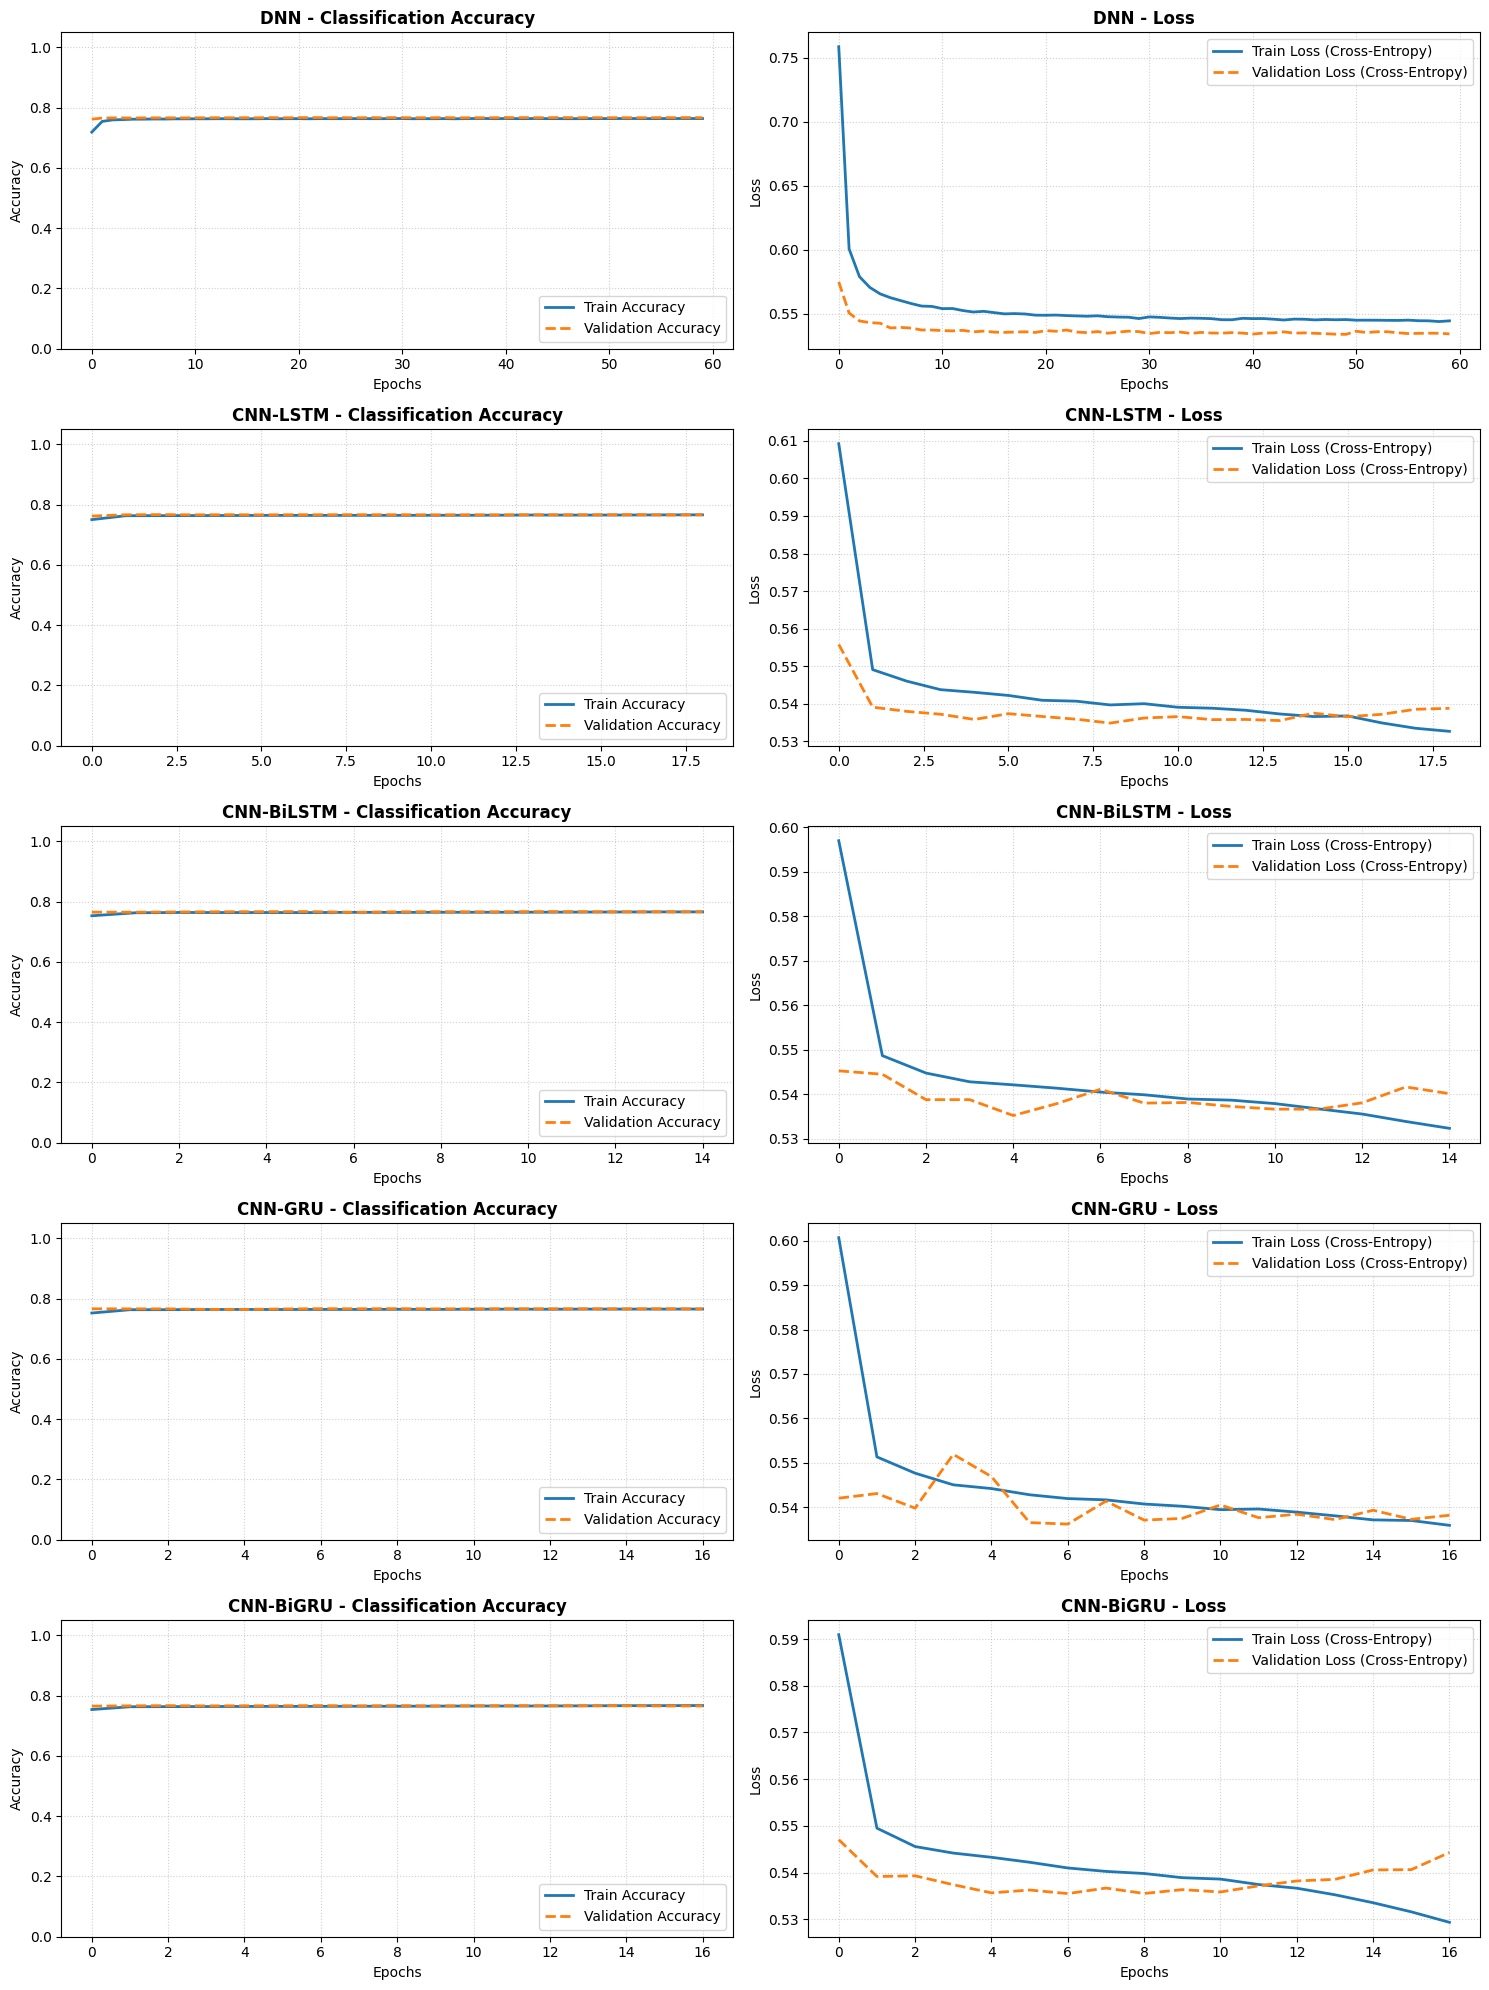

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# # Set visual style
# sns.set_theme(style="whitegrid")

num_models = len(hybrid_dl_models_history)
fig, axes = plt.subplots(num_models, 2, figsize=(15, 4 * num_models))

# Ensure axes is 2D even if only 1 model is plotted
if num_models == 1:
    axes = np.expand_dims(axes, axis=0)

for i, (name, history) in enumerate(hybrid_dl_models_history.items()):
    
    # ---------------- 1. Plot Accuracy ----------------
    axes[i, 0].plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
    axes[i, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2, linestyle='--')    
    axes[i, 0].set_title(f'{name} - Classification Accuracy', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Epochs', fontsize=10)
    axes[i, 0].set_ylabel('Accuracy', fontsize=10)
    axes[i, 0].set_ylim([0, 1.05])  # Accuracy bounded between 0 and 1
    axes[i, 0].legend(loc='lower right', frameon=True)
    axes[i, 0].grid(True, linestyle=':', alpha=0.6)

    # ---------------- 2. Plot Loss ----------------
    axes[i, 1].plot(history.history['loss'], label='Train Loss (Cross-Entropy)', color='#1f77b4', linewidth=2)
    axes[i, 1].plot(history.history['val_loss'], label='Validation Loss (Cross-Entropy)', color='#ff7f0e', linewidth=2, linestyle='--')    
    axes[i, 1].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('Epochs', fontsize=10)
    axes[i, 1].set_ylabel('Loss', fontsize=10)
    axes[i, 1].legend(loc='upper right', frameon=True)
    axes[i, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Different DL Models Output Comparisons

In [31]:
import joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# ---------------- 1. Feature Extraction & Preprocessing ----------------
# Select all 24 independent features
X_full = df.iloc[:, :24].copy()

# Encode categorical feature columns
encoders = joblib.load('Label-Encoder.bin')
for column in X_full.select_dtypes(include='object'):
    if column in encoders:
        X_full[column] = encoders[column].transform(X_full[column])

# Scale full feature set using saved RobustScaler
scaler = joblib.load('Robust-Scaler.bin')
X_full_scaled = scaler.transform(X_full)

print("🚀 Generating multiclass predictions for the full dataset using all Deep Learning models...\n")

# ---------------- 2. Model Loading & Prediction Loop ----------------
for name in hybrid_dl_models.keys():
    # Sanitize name to match saved checkpoint filenames (e.g. CNN-LSTM -> CNN_LSTM_Model.keras)
    sanitized_name = name.replace('/', '_').replace(' ', '_')
    model_path = f'{sanitized_name}_Model.keras'
    
    saved_model = load_model(model_path)
    
    # Get softmax probabilities of shape (N, 8)
    raw_probabilities = saved_model.predict(X_full_scaled, batch_size=64, verbose=0)
    
    # Extract the predicted class index (0 to 7) with highest probability
    predicted_classes = np.argmax(raw_probabilities, axis=1)
    
    # Store predicted class integer in DataFrame
    df[f'{name}_Predicted_Class'] = predicted_classes

# ---------------- 3. Save Final Dataset ----------------
output_file = 'patient_multidisease_with_all_predictions.csv'
df.to_csv(output_file, index=False)
print(f"✅ Predictions saved successfully to: {output_file}\n")

# ---------------- 4. Display Results ----------------
# Determine actual target column name (assuming target is column 24 or named 'battery_health_class')
target_col = df.columns[24] if len(df.columns) > 24 else df.columns[-1]

display_columns = [target_col] + [f'{name}_Predicted_Class' for name in hybrid_dl_models.keys()]
display(df[display_columns].head(10))

🚀 Generating multiclass predictions for the full dataset using all Deep Learning models...

✅ Predictions saved successfully to: patient_multidisease_with_all_predictions.csv



,sublabel,DNN_Predicted_Class,CNN-LSTM_Predicted_Class,CNN-BiLSTM_Predicted_Class,CNN-GRU_Predicted_Class,CNN-BiGRU_Predicted_Class
0,7,7,7,7,7,7
1,7,7,7,7,7,7
2,7,7,7,7,7,7
3,7,7,7,7,7,7
4,7,7,7,7,7,7
5,7,7,7,7,7,7
6,7,7,7,7,7,7
7,7,7,7,7,7,7
8,7,7,7,7,7,7
9,7,7,7,7,7,7
